In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
orders = pd.read_csv("../data/processed/shopee_orders_thailand.csv")
order_items = pd.read_csv("../data/processed/shopee_order_items_thailand.csv")
customers = pd.read_csv("../data/processed/shopee_customers_thailand.csv")
products = pd.read_csv("../data/processed/shopee_products_thailand.csv")
product_campaigns = pd.read_csv("../data/processed/shopee_product_campaign_thailand.csv")
sellers = pd.read_csv("../data/processed/shopee_sellers_thailand.csv")
campaigns = pd.read_csv("../data/processed/shopee_campaigns_thailand.csv")
shipments = pd.read_csv("../data/processed/shopee_shipments_thailand.csv")

# Doanh thu Shopee Thái Lan của 200 shop (2022-2025)

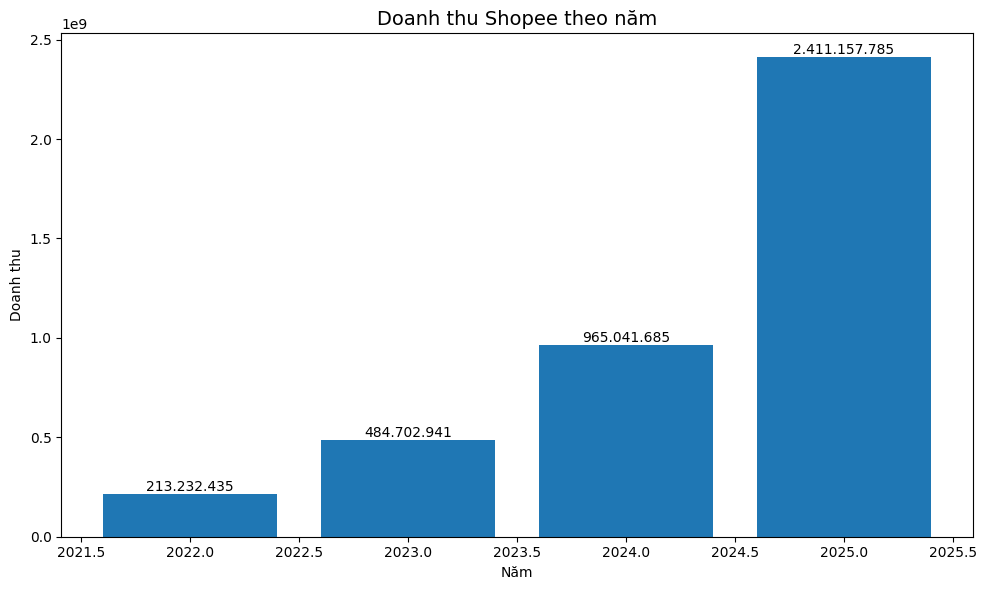

In [3]:
df = orders.merge(order_items, on="order_id")
df["Doanh Thu"] = df["unit_price_after_discount"] * df["quantity"]
df["year"] = pd.to_datetime(df["order_date"]).dt.year

Doanh_thu = df.groupby("year")["Doanh Thu"].sum().reset_index()

plt.figure(figsize=(10,6))

bars = plt.bar(Doanh_thu["year"], Doanh_thu["Doanh Thu"])

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, 
             f'{y:,.0f}'.replace(",", "."), 
             ha='center', va='bottom')

plt.title("Doanh thu Shopee theo năm", fontsize=14)
plt.xlabel("Năm")
plt.ylabel("Doanh thu")

plt.tight_layout()
plt.show()

# DOANH SỐ THEO CAMPAIGN THEO NĂM

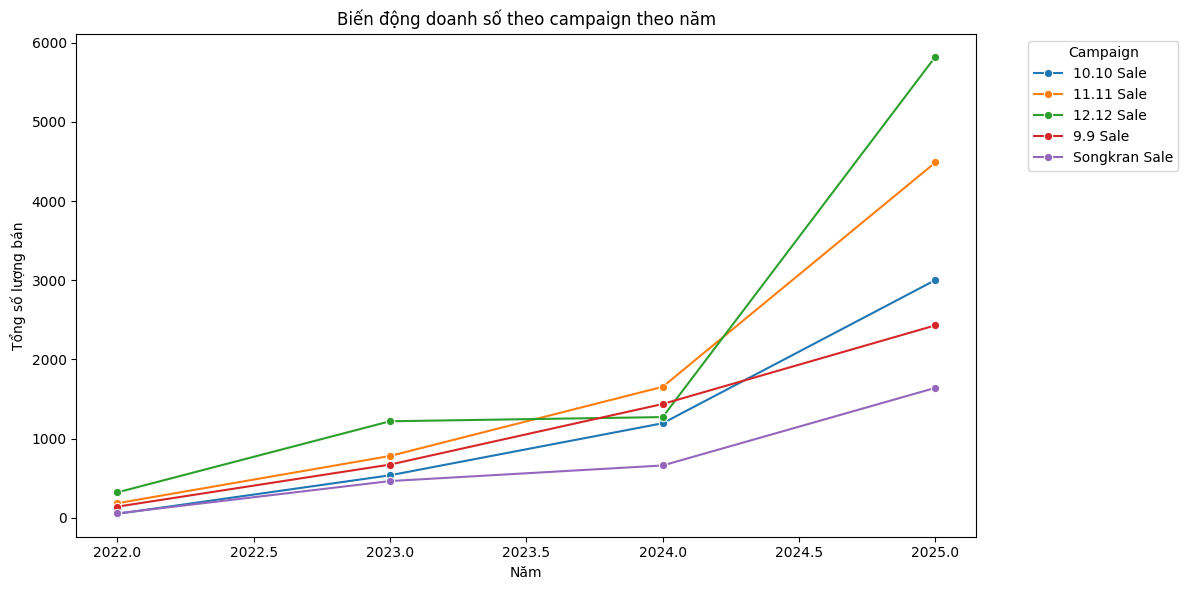

In [4]:
df = (
    order_items
    .merge(orders[['order_id','campaign_id','order_date']], on='order_id')
    .merge(campaigns, on='campaign_id')
)

df['year'] = pd.to_datetime(df['order_date']).dt.year

campaign_year = df.groupby(['campaign_name','year'])['quantity'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=campaign_year, x="year", y="quantity", hue="campaign_name", marker="o")

plt.title("Biến động doanh số theo campaign theo năm")
plt.xlabel("Năm")
plt.ylabel("Tổng số lượng bán")
plt.legend(title="Campaign", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# SỐ ĐƠN HÀNG THEO QUÝ

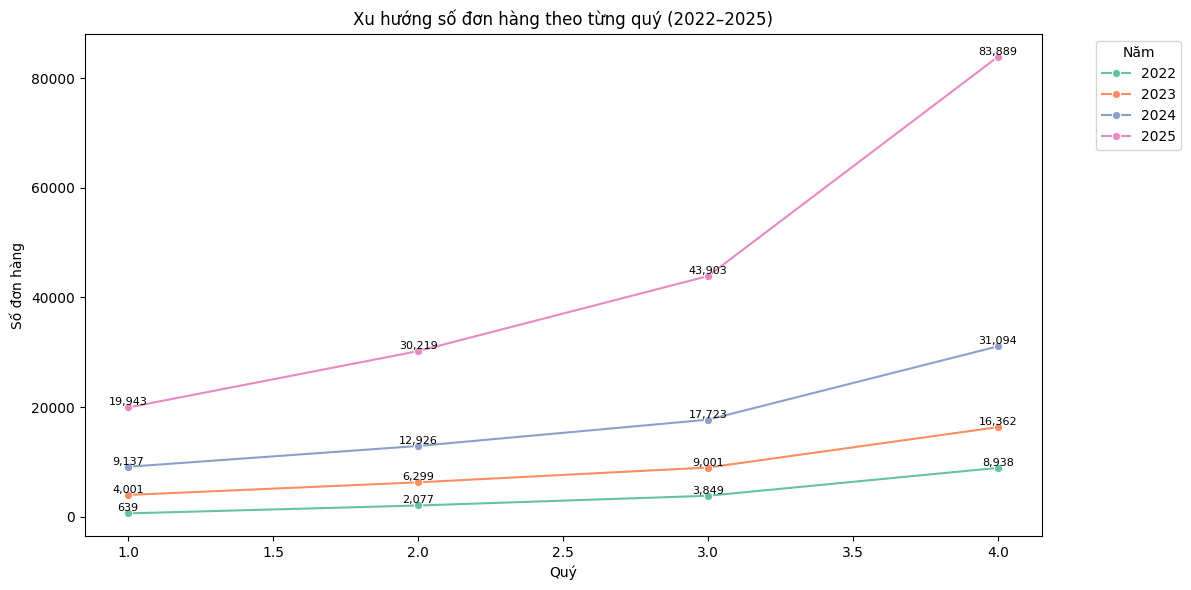

In [6]:
plt.figure(figsize=(12,6))

ax = sns.lineplot(
    data=orders_by_quarter_year,
    x="quarter",
    y="num_orders",
    hue="year",
    marker="o",
    palette="Set2"
)

for _, row in orders_by_quarter_year.iterrows():
    plt.text(
        row["quarter"],
        row["num_orders"],
        f'{row["num_orders"]:,}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Xu hướng số đơn hàng theo từng quý (2022–2025)")
plt.xlabel("Quý")
plt.ylabel("Số đơn hàng")
plt.legend(title="Năm", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# MÙA VỤ DOANH SỐ THEO THÁNG/ NĂM

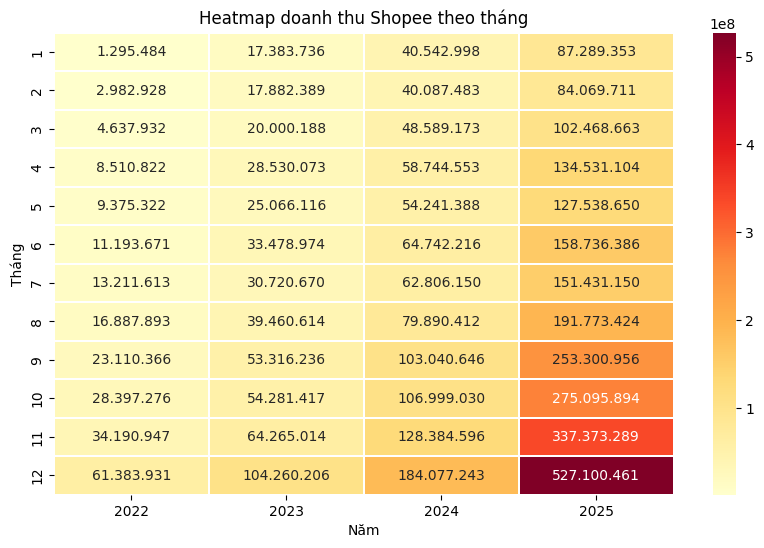

In [14]:
annot_labels = pivot.round(0).astype(int).astype(str)

annot_labels = annot_labels.apply(
    lambda col: col.map(lambda x: f"{int(x):,}".replace(",", "."))
)
pivot = df.pivot_table(
    values='revenue',
    index='month',
    columns='year',
    aggfunc='sum'
)
#heatmap mùa vụ
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    annot=annot_labels,
    fmt="",
    linewidths=0.3
)

plt.title("Heatmap doanh thu Shopee theo tháng")
plt.ylabel("Tháng")
plt.xlabel("Năm")
plt.show()

# KHÁCH HÀNG THEO NHÓM TUỔI VÀ DANH MỤC ĐƯỢC MUA NHIỀU NHẤT

age_group
46-60    72905
26-35    70218
60+      59593
36-45    57361
18-25    39388
<18        535
Name: order_id, dtype: int64


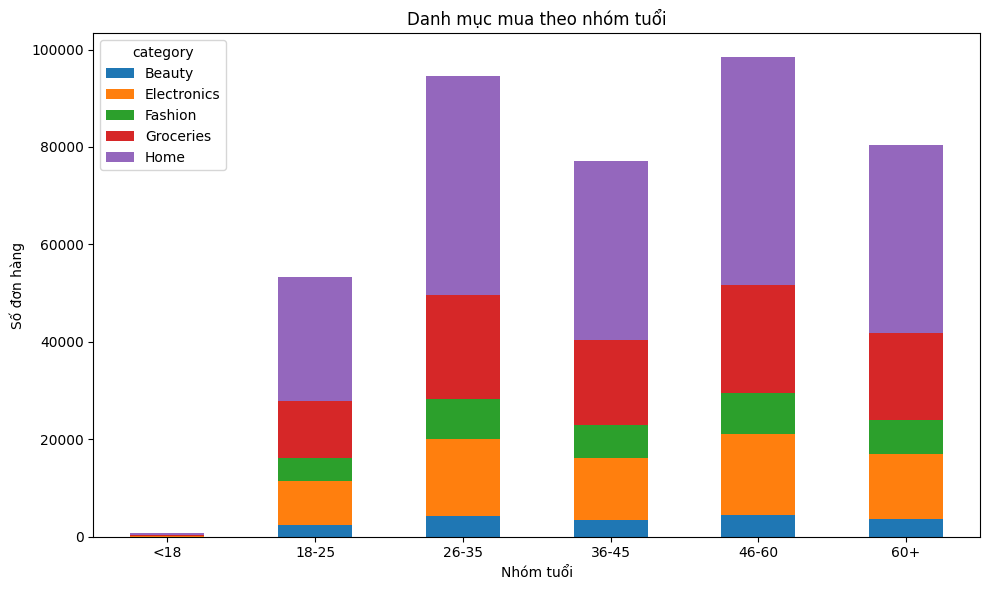

In [17]:
customers["dob"] = pd.to_datetime(customers["dob"])

today = pd.to_datetime("today")

customers["age"] = today.year - customers["dob"].dt.year - (
    (today.month < customers["dob"].dt.month) |
    ((today.month == customers["dob"].dt.month) & (today.day < customers["dob"].dt.day))
)

customers["age_group"] = pd.cut(
    customers["age"],
    bins=[0, 18, 25, 35, 45, 60, 100],
    labels=["<18", "18-25", "26-35", "36-45", "46-60", "60+"]
)

df = order_items.merge(orders, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(customers[["customer_id", "age_group"]], on="customer_id", how="left")

age_purchase = df.groupby("age_group")["order_id"].nunique()

print(age_purchase.sort_values(ascending=False))

pivot = df.pivot_table(
    values="order_id",
    index="age_group",
    columns="category",
    aggfunc="nunique",
    fill_value=0
)

pivot.plot(kind="bar", stacked=True, figsize=(10,6))

plt.title("Danh mục mua theo nhóm tuổi")
plt.xlabel("Nhóm tuổi")
plt.ylabel("Số đơn hàng")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# DOANH SỐ THEO DANH MỤC SẢN PHẨM

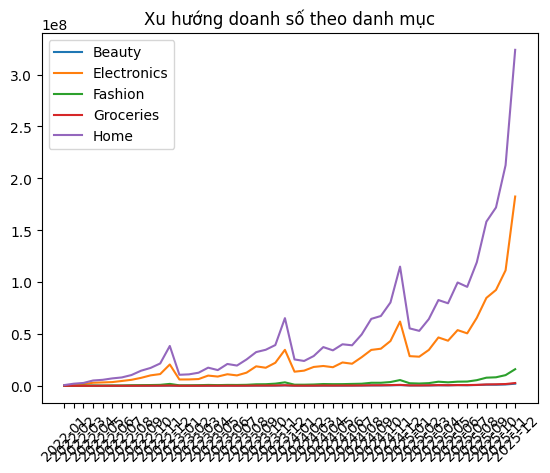

In [18]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.to_period('M')
df['revenue'] = df['quantity'] * df['unit_price']
#xu hướng danh mục
cat_trend = df.groupby(['month','category'])['revenue'].sum().reset_index()

for cat in cat_trend['category'].unique():
    subset = cat_trend[cat_trend['category'] == cat]
    plt.plot(subset['month'].astype(str), subset['revenue'], label=cat)

plt.xticks(rotation=45)
plt.title("Xu hướng doanh số theo danh mục")
plt.legend()
plt.show()

# PHÂN PHỐI SỐ KHÁCH HÀNG MỚI TRONG THÁNG VỚI TỔNG SỐ KHÁCH HÀNG CỦA SÀN

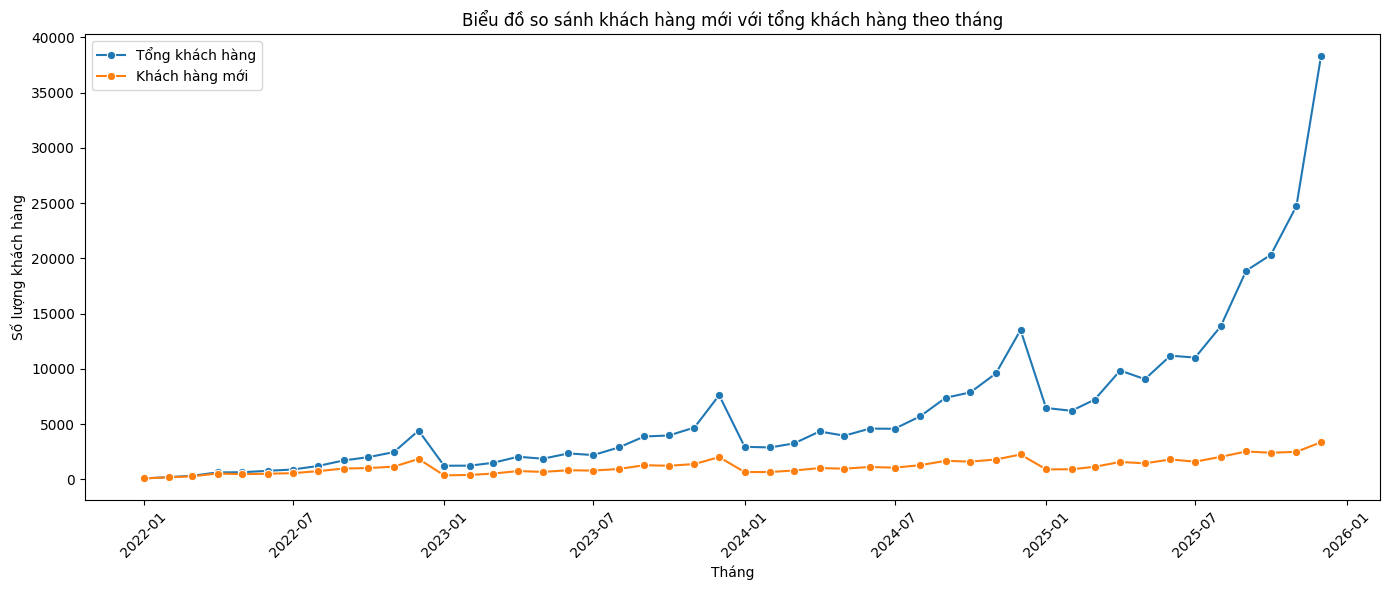

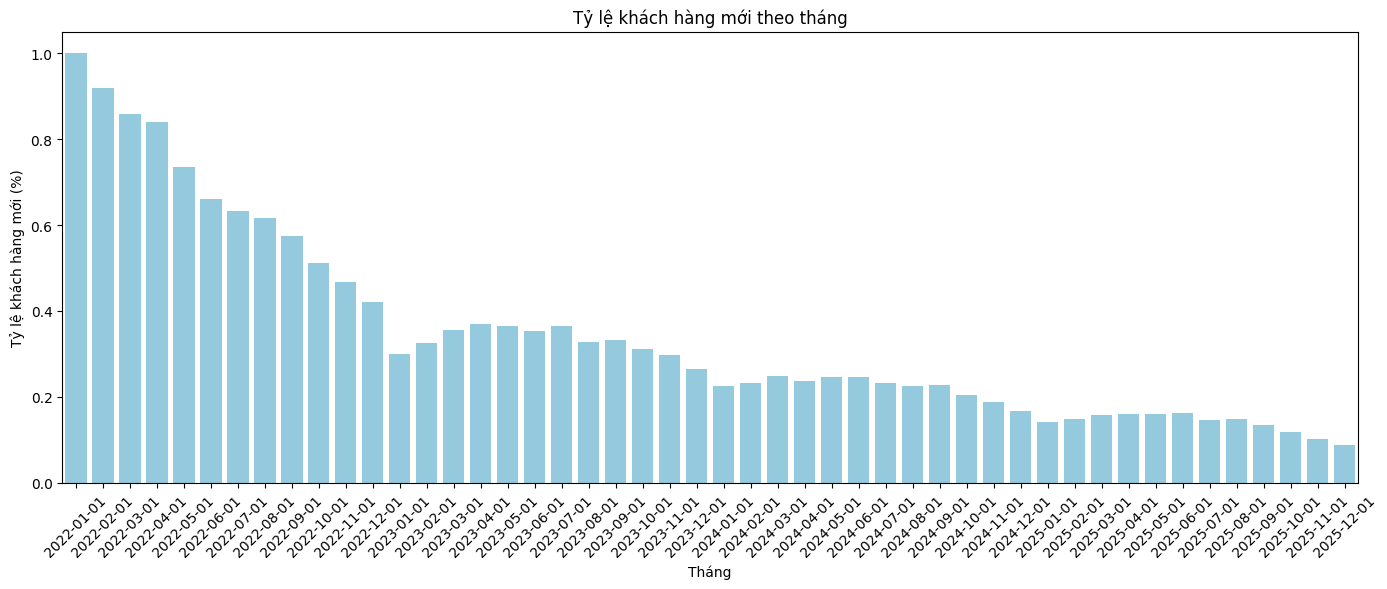

In [27]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['year_month'] = orders['order_date'].dt.to_period('M').dt.to_timestamp()

first_purchase = orders.groupby('customer_id')['order_date'].min().reset_index()
first_purchase['year_month'] = first_purchase['order_date'].dt.to_period('M').dt.to_timestamp()

new_customers = first_purchase.groupby('year_month')['customer_id'].nunique().reset_index(name='new_customers')

total_customers = orders.groupby('year_month')['customer_id'].nunique().reset_index(name='total_customers')

customer_stats = pd.merge(total_customers, new_customers, on='year_month', how='left')
customer_stats['new_ratio'] = customer_stats['new_customers'] / customer_stats['total_customers']

plt.figure(figsize=(14,6))
sns.lineplot(data=customer_stats, x="year_month", y="total_customers", label="Tổng khách hàng", marker="o")
sns.lineplot(data=customer_stats, x="year_month", y="new_customers", label="Khách hàng mới", marker="o")
plt.title("Biểu đồ so sánh khách hàng mới với tổng khách hàng theo tháng")
plt.xlabel("Tháng")
plt.ylabel("Số lượng khách hàng")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Vẽ tỷ lệ khách hàng mới
plt.figure(figsize=(14,6))
sns.barplot(data=customer_stats, x="year_month", y="new_ratio", color="skyblue")
plt.title("Tỷ lệ khách hàng mới theo tháng")
plt.xlabel("Tháng")
plt.ylabel("Tỷ lệ khách hàng mới (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# SỐ KHÁCH HÀNG CHỈ MUA MỘT LẦN VÀ DOANH THU TỪ NGUỒN KHÁCH HÀNG NÀY MANG LẠI

Doanh thu từ khách hàng mua 1 lần: 83,808,901
Tỷ trọng doanh thu: 2.03%


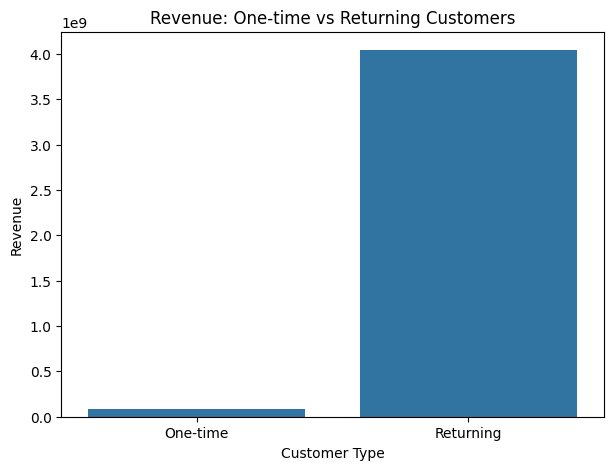

In [29]:
# Số lần mua của mỗi khách hàng
customer_orders_count = (
    orders.groupby("customer_id")["order_id"]
    .nunique()
    .reset_index(name="num_orders")
)

# Khách hàng chỉ mua 1 lần
one_time_customers = customer_orders_count[
    customer_orders_count["num_orders"] == 1
]

one_time_orders = orders.merge(
    one_time_customers[["customer_id"]],
    on="customer_id",
    how="inner"
)

# Tổng doanh thu
one_time_revenue = one_time_orders["total_amount"].sum()

print(f"Doanh thu từ khách hàng mua 1 lần: {one_time_revenue:,.0f}")
total_revenue = orders["total_amount"].sum()

revenue_ratio = one_time_revenue / total_revenue * 100

print(f"Tỷ trọng doanh thu: {revenue_ratio:.2f}%")
revenue_compare = pd.DataFrame({
    "Customer Type": ["One-time", "Returning"],
    "Revenue": [
        one_time_revenue,
        total_revenue - one_time_revenue
    ]
})

plt.figure(figsize=(7,5))

sns.barplot(
    data=revenue_compare,
    x="Customer Type",
    y="Revenue"
)

plt.title("Revenue: One-time vs Returning Customers")
plt.show()

# HEATMAP SỐ ĐƠN HÀNG THEO THỜI GIAN VÀ KHU VỰC

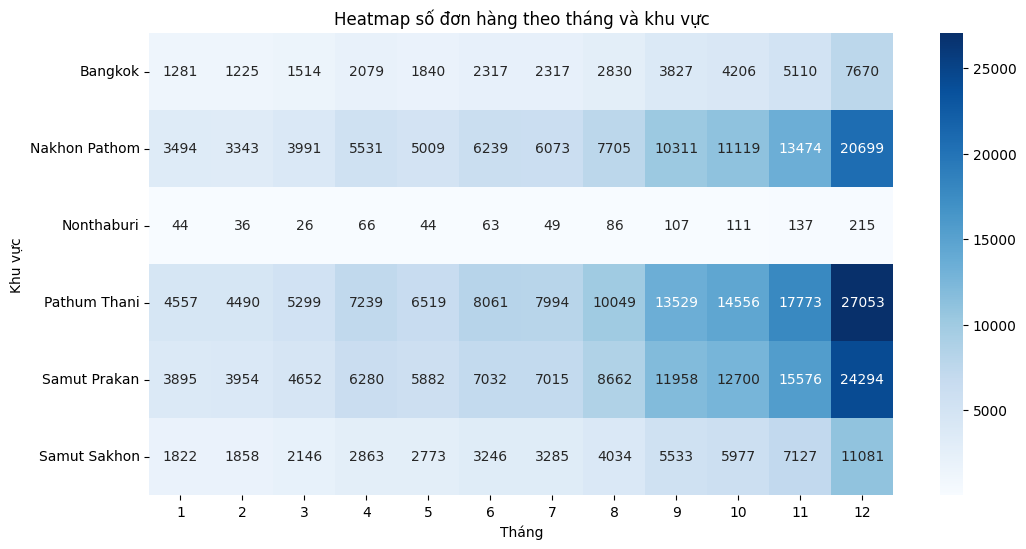

In [26]:
df = order_items.merge(orders, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(sellers[["seller_id", "city", "province"]], on="seller_id", how="left")

df["order_date"] = pd.to_datetime(df["order_date"])
df["revenue"] = df["quantity"] * df["unit_price"]
df["month"] = df["order_date"].dt.month
orders_region = df.pivot_table(
    values="order_id",
    index="province",
    columns="month",
    aggfunc="nunique",
    fill_value=0
)

plt.figure(figsize=(12,6))

sns.heatmap(
    orders_region,
    cmap="Blues",
    annot=True,
    fmt=".0f"
)

plt.title("Heatmap số đơn hàng theo tháng và khu vực")
plt.xlabel("Tháng")
plt.ylabel("Khu vực")
plt.show()